In [1]:
import requests
import os
from dotenv import load_dotenv

load_dotenv()

session = requests.Session()
resp = session.post(
    "https://www.space-track.org/ajaxauth/login",
    data={"identity": os.getenv("ST_USER"), "password": os.getenv("ST_PASS")},
    timeout=15  # fail fast instead of hanging forever
)
print(f"Login status: {resp.status_code}")

# Small test query with an explicit timeout
url = "https://www.space-track.org/basicspacedata/query/class/gp/EPOCH/%3Enow-30/OBJECT_TYPE/PAYLOAD/orderby/NORAD_CAT_ID/format/tle/limit/5"
resp2 = session.get(url, timeout=20)
print(f"Query status: {resp2.status_code}")
print(resp2.text[:200])

Login status: 200
Query status: 200
1 00005U 58002B   26195.41072703  .00000153  00000-0  17136-3 0  9997
2 00005  34.2538 230.3154 1837093 261.2503  77.6771 10.86016055446247
1 00011U 59001A   26195.65000549  .00000733  00000-0  3662


In [2]:
url = (
    "https://www.space-track.org/basicspacedata/query/class/gp/"
    "EPOCH/%3Enow-30/OBJECT_TYPE/PAYLOAD/MEAN_MOTION/%3E11.25/"
    "orderby/NORAD_CAT_ID/format/tle/limit/5000"
)

import time
start = time.time()
resp = session.get(url, timeout=60)
elapsed = time.time() - start

print(f"Status: {resp.status_code}")
print(f"Completed in {elapsed:.1f} seconds")

lines = resp.text.strip().splitlines()
print(f"Total lines: {len(lines)}")
print(f"Total objects: {len(lines) // 2}")

with open("data/tle_raw_5k.txt", "w") as f:
    f.write(resp.text)
print("Saved to data/tle_raw_5k.txt")

Status: 200
Completed in 0.6 seconds
Total lines: 10000
Total objects: 5000
Saved to data/tle_raw_5k.txt


In [3]:
from sgp4.api import Satrec, jday
from datetime import datetime, timedelta
import numpy as np
import time

with open("data/tle_raw_5k.txt", "r") as f:
    lines_5k = f.read().strip().splitlines()

satellites_5k = []
for i in range(0, len(lines_5k), 2):
    sat = Satrec.twoline2rv(lines_5k[i], lines_5k[i + 1])
    satellites_5k.append(sat)

print(f"Parsed {len(satellites_5k)} satellites")

# Same 24-hour window, 5-minute steps as before
start_time = datetime.utcnow()
time_step_minutes = 5
num_steps = 288
time_points_5k = [start_time + timedelta(minutes=i * time_step_minutes) for i in range(num_steps)]

print(f"\nPropagating {len(satellites_5k)} satellites across {num_steps} time steps...")
start = time.time()

all_positions_5k = np.zeros((len(satellites_5k), num_steps, 3))
all_errors_5k = np.zeros((len(satellites_5k), num_steps), dtype=int)

for sat_idx, sat in enumerate(satellites_5k):
    for t_idx, t in enumerate(time_points_5k):
        jd, fr = jday(t.year, t.month, t.day, t.hour, t.minute, t.second)
        error, position, velocity = sat.sgp4(jd, fr)
        all_positions_5k[sat_idx, t_idx] = position
        all_errors_5k[sat_idx, t_idx] = error

elapsed = time.time() - start
print(f"Propagation completed in {elapsed:.1f} seconds")
print(f"Positions array shape: {all_positions_5k.shape}")
print(f"Errors: {np.sum(all_errors_5k != 0)} out of {all_errors_5k.size}")

Parsed 5000 satellites

Propagating 5000 satellites across 288 time steps...
Propagation completed in 1.4 seconds
Positions array shape: (5000, 288, 3)
Errors: 14850 out of 1440000


In [4]:
valid_mask_5k = ~np.any(all_errors_5k != 0, axis=1)

clean_satellites_5k = [sat for i, sat in enumerate(satellites_5k) if valid_mask_5k[i]]
clean_positions_5k = all_positions_5k[valid_mask_5k]
clean_indices_5k = np.where(valid_mask_5k)[0]

norad_ids_5k = [sat.satnum for sat in clean_satellites_5k]

print(f"Kept {len(clean_satellites_5k)} clean satellites out of {len(satellites_5k)}")
print(f"Clean positions shape: {clean_positions_5k.shape}")

Kept 4948 clean satellites out of 5000
Clean positions shape: (4948, 288, 3)


In [5]:
from scipy.spatial import cKDTree
import time

SCREENING_DISTANCE_KM = 25.0

close_approaches_5k = []

start = time.time()
for t_idx in range(clean_positions_5k.shape[1]):
    positions_at_t = clean_positions_5k[:, t_idx, :]
    tree = cKDTree(positions_at_t)
    pairs = tree.query_pairs(r=SCREENING_DISTANCE_KM)
    
    for i, j in pairs:
        dist = np.linalg.norm(positions_at_t[i] - positions_at_t[j])
        close_approaches_5k.append((i, j, t_idx, dist))

elapsed = time.time() - start
print(f"Screening completed in {elapsed:.1f} seconds")
print(f"Found {len(close_approaches_5k)} close-approach events within {SCREENING_DISTANCE_KM} km")

import pandas as pd
df_5k = pd.DataFrame(close_approaches_5k, columns=["sat_i", "sat_j", "time_idx", "distance_km"])
closest_per_pair_5k = df_5k.loc[df_5k.groupby(["sat_i", "sat_j"])["distance_km"].idxmin()]
closest_per_pair_5k = closest_per_pair_5k.sort_values("distance_km").reset_index(drop=True)

print(f"\nUnique satellite pairs with a close approach: {len(closest_per_pair_5k)}")
print(f"\nDistribution of closest distances:")
print(closest_per_pair_5k["distance_km"].describe())

Screening completed in 0.4 seconds
Found 6998 close-approach events within 25.0 km

Unique satellite pairs with a close approach: 868

Distribution of closest distances:
count    868.000000
mean      17.521555
std        5.650208
min        0.000000
25%       14.121892
50%       18.637330
75%       22.069938
max       24.941886
Name: distance_km, dtype: float64


In [6]:
# Step 6a: Extract orbital elements for every clean satellite (no propagation needed - these come directly from the TLE)
orbital_features = []
for sat in clean_satellites_5k:
    orbital_features.append({
        "norad_id": sat.satnum,
        "inclination": sat.inclo,      # radians
        "raan": sat.nodeo,              # radians
        "eccentricity": sat.ecco,
        "arg_perigee": sat.argpo,       # radians
        "mean_motion": sat.no_kozai,    # radians/minute
        "mean_anomaly": sat.mo          # radians
    })

orbit_df = pd.DataFrame(orbital_features)
print(f"Extracted orbital elements for {len(orbit_df)} satellites")
print(orbit_df.head())

Extracted orbital elements for 4948 satellites
   norad_id  inclination      raan  eccentricity  arg_perigee  mean_motion  \
0        11     0.573780  5.954894      0.144551     3.721815     0.051949   
1        20     0.581966  2.909268      0.163771     3.540603     0.050701   
2        22     0.876901  5.613776      0.007721     4.155346     0.066733   
3        29     0.844341  4.391943      0.002181     0.487678     0.064525   
4        45     1.164030  4.992226      0.024359     2.444288     0.062657   

   mean_anomaly  
0      2.388651  
1      2.600666  
2      2.116381  
3      5.799137  
4      3.872606  


In [7]:
def angle_diff(a1, a2):
    """Smallest angular difference between two angles (radians), handling wraparound"""
    diff = np.abs(a1 - a2) % (2 * np.pi)
    return np.minimum(diff, 2 * np.pi - diff)

def build_features(idx_i, idx_j, orbit_df):
    row_i = orbit_df.iloc[idx_i]
    row_j = orbit_df.iloc[idx_j]
    return {
        "incl_diff": abs(row_i["inclination"] - row_j["inclination"]),
        "raan_diff": angle_diff(row_i["raan"], row_j["raan"]),
        "ecc_diff": abs(row_i["eccentricity"] - row_j["eccentricity"]),
        "argp_diff": angle_diff(row_i["arg_perigee"], row_j["arg_perigee"]),
        "mean_motion_diff": abs(row_i["mean_motion"] - row_j["mean_motion"]),
        "mean_anomaly_diff": angle_diff(row_i["mean_anomaly"], row_j["mean_anomaly"]),
    }

# Positive examples: real close-approach pairs from Step 5
positive_rows = []
for _, row in closest_per_pair_5k.iterrows():
    feats = build_features(int(row["sat_i"]), int(row["sat_j"]), orbit_df)
    feats["label"] = 1
    positive_rows.append(feats)

# Negative examples: random pairs NOT in the close-approach set
positive_pairs_set = set(zip(closest_per_pair_5k["sat_i"].astype(int), closest_per_pair_5k["sat_j"].astype(int)))
n_satellites = len(clean_satellites_5k)

np.random.seed(42)
negative_rows = []
n_negatives_needed = len(positive_rows) * 3  # 3:1 negative:positive ratio, common for imbalanced problems

while len(negative_rows) < n_negatives_needed:
    i, j = np.random.randint(0, n_satellites, size=2)
    if i == j:
        continue
    pair = (min(i, j), max(i, j))
    if pair in positive_pairs_set:
        continue
    feats = build_features(pair[0], pair[1], orbit_df)
    feats["label"] = 0
    negative_rows.append(feats)

ml_dataset = pd.DataFrame(positive_rows + negative_rows)
print(f"Total dataset: {len(ml_dataset)} rows")
print(f"Positive (close approach): {(ml_dataset['label']==1).sum()}")
print(f"Negative (no close approach): {(ml_dataset['label']==0).sum()}")
print(f"\n{ml_dataset.head()}")

Total dataset: 3472 rows
Positive (close approach): 868
Negative (no close approach): 2604

   incl_diff  raan_diff  ecc_diff  argp_diff  mean_motion_diff  \
0        0.0        0.0       0.0        0.0               0.0   
1        0.0        0.0       0.0        0.0               0.0   
2        0.0        0.0       0.0        0.0               0.0   
3        0.0        0.0       0.0        0.0               0.0   
4        0.0        0.0       0.0        0.0               0.0   

   mean_anomaly_diff  label  
0                0.0      1  
1                0.0      1  
2                0.0      1  
3                0.0      1  
4                0.0      1  


In [8]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score
import xgboost as xgb

feature_cols = ["incl_diff", "raan_diff", "ecc_diff", "argp_diff", "mean_motion_diff", "mean_anomaly_diff"]

X = ml_dataset[feature_cols]
y = ml_dataset["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {len(X_train)} rows ({y_train.sum()} positive)")
print(f"Test: {len(X_test)} rows ({y_test.sum()} positive)")

model = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    scale_pos_weight=(y_train==0).sum() / (y_train==1).sum(),  # correct for class imbalance
    random_state=42
)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=["No close approach", "Close approach"]))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob):.4f}")

Train: 2777 rows (694 positive)
Test: 695 rows (174 positive)

Classification Report:
                   precision    recall  f1-score   support

No close approach       0.99      0.92      0.95       521
   Close approach       0.80      0.96      0.87       174

         accuracy                           0.93       695
        macro avg       0.89      0.94      0.91       695
     weighted avg       0.94      0.93      0.93       695

ROC-AUC: 0.9758


In [9]:
importance = pd.DataFrame({
    "feature": feature_cols,
    "importance": model.feature_importances_
}).sort_values("importance", ascending=False)

print(importance.to_string(index=False))

          feature  importance
 mean_motion_diff    0.736300
         ecc_diff    0.090317
        raan_diff    0.068580
        argp_diff    0.038278
        incl_diff    0.036132
mean_anomaly_diff    0.030393


In [10]:
# Save the trained model and feature importance for reference
import joblib
joblib.dump(model, "data/triage_model.joblib")
importance.to_csv("data/feature_importance.csv", index=False)
print("Saved model and feature importance to data/")

Saved model and feature importance to data/


In [11]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

# 5-fold stratified CV preserves the positive/negative ratio in every fold
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = cross_val_score(
    xgb.XGBClassifier(
        n_estimators=100,
        max_depth=4,
        learning_rate=0.1,
        scale_pos_weight=(y==0).sum() / (y==1).sum(),
        random_state=42
    ),
    X, y,
    cv=cv,
    scoring="roc_auc"
)

print(f"Cross-validated ROC-AUC scores: {cv_scores}")
print(f"Mean: {cv_scores.mean():.4f}")
print(f"Std:  {cv_scores.std():.4f}")

Cross-validated ROC-AUC scores: [0.96987447 0.97773954 0.97456897 0.97265707 0.9739718 ]
Mean: 0.9738
Std:  0.0026


In [12]:
from sklearn.metrics import precision_recall_curve

precisions, recalls, thresholds = precision_recall_curve(y_test, y_prob)

target_recall = 0.99
valid_idx = np.where(recalls[:-1] >= target_recall)[0]

if len(valid_idx) > 0:
    # Among thresholds achieving target recall, pick the one with highest precision
    best_idx = valid_idx[np.argmax(precisions[valid_idx])]
    best_threshold = thresholds[best_idx]
    print(f"Threshold for >= {target_recall*100:.0f}% recall: {best_threshold:.4f}")
    print(f"  Precision at this threshold: {precisions[best_idx]:.4f}")
    print(f"  Recall at this threshold: {recalls[best_idx]:.4f}")
else:
    print(f"No threshold achieves {target_recall*100:.0f}% recall")

# Compare against the default 0.5 threshold
default_pred = (y_prob >= 0.5).astype(int)
tuned_pred = (y_prob >= best_threshold).astype(int)

print(f"\n--- Default threshold (0.5) ---")
print(classification_report(y_test, default_pred, target_names=["No close approach", "Close approach"]))

print(f"\n--- Tuned threshold ({best_threshold:.4f}) ---")
print(classification_report(y_test, tuned_pred, target_names=["No close approach", "Close approach"]))

Threshold for >= 99% recall: 0.0372
  Precision at this threshold: 0.6732
  Recall at this threshold: 0.9943

--- Default threshold (0.5) ---
                   precision    recall  f1-score   support

No close approach       0.99      0.92      0.95       521
   Close approach       0.80      0.96      0.87       174

         accuracy                           0.93       695
        macro avg       0.89      0.94      0.91       695
     weighted avg       0.94      0.93      0.93       695


--- Tuned threshold (0.0372) ---
                   precision    recall  f1-score   support

No close approach       1.00      0.84      0.91       521
   Close approach       0.67      0.99      0.80       174

         accuracy                           0.88       695
        macro avg       0.84      0.92      0.86       695
     weighted avg       0.92      0.88      0.88       695



In [13]:
from sklearn.calibration import calibration_curve

prob_true, prob_pred = calibration_curve(y_test, y_prob, n_bins=10)

print("Predicted probability vs. actual observed frequency:")
for pt, pp in zip(prob_true, prob_pred):
    print(f"  Predicted: {pp:.3f}   Actual: {pt:.3f}")

from sklearn.metrics import brier_score_loss
brier = brier_score_loss(y_test, y_prob)
print(f"\nBrier score: {brier:.4f}")

Predicted probability vs. actual observed frequency:
  Predicted: 0.008   Actual: 0.004
  Predicted: 0.136   Actual: 0.111
  Predicted: 0.236   Actual: 0.143
  Predicted: 0.349   Actual: 0.667
  Predicted: 0.457   Actual: 0.125
  Predicted: 0.547   Actual: 0.400
  Predicted: 0.661   Actual: 0.500
  Predicted: 0.764   Actual: 0.647
  Predicted: 0.860   Actual: 0.727
  Predicted: 0.966   Actual: 0.885

Brier score: 0.0556


In [14]:
import json

model_summary = {
    "cross_validated_roc_auc_mean": float(cv_scores.mean()),
    "cross_validated_roc_auc_std": float(cv_scores.std()),
    "default_threshold_recall": 0.96,
    "default_threshold_precision": 0.80,
    "tuned_threshold": float(best_threshold),
    "tuned_threshold_recall": float(recalls[best_idx]),
    "tuned_threshold_precision": float(precisions[best_idx]),
    "brier_score": float(brier)
}

with open("data/model_summary.json", "w") as f:
    json.dump(model_summary, f, indent=2)

print("Saved model summary to data/model_summary.json")

Saved model summary to data/model_summary.json


In [15]:
import time

# Baseline: time to do FULL propagation + screening on all 4,944 satellites

start = time.time()
tree_full = cKDTree(clean_positions_5k[:, 0, :])  # single time step for a fair per-timestep comparison
pairs_full = tree_full.query_pairs(r=SCREENING_DISTANCE_KM)
full_screening_time = time.time() - start

# Triage approach: only compute full geometry for pairs the model flags
# Step A: score ALL possible pairs using cheap orbital-element features (no propagation)
start = time.time()

all_pairs_idx = list(zip(*np.triu_indices(len(clean_satellites_5k), k=1)))
print(f"Total possible pairs: {len(all_pairs_idx)}")

# Build features for ALL pairs (this is the "cheap" step - no propagation)
triage_features = []
for i, j in all_pairs_idx:
    triage_features.append(build_features(i, j, orbit_df))

triage_X = pd.DataFrame(triage_features)
triage_probs = model.predict_proba(triage_X)[:, 1]

triage_scoring_time = time.time() - start

# Flag pairs above the tuned threshold - these are the ONLY ones that would need full propagation
flagged_mask = triage_probs >= best_threshold
n_flagged = flagged_mask.sum()

print(f"\nFull brute-force pairs per timestep: {len(pairs_full)} pairs found (from {len(all_pairs_idx):,} possible)")
print(f"Screening time (1 timestep): {full_screening_time:.4f} sec")

print(f"\nTriage model scoring time (ALL {len(all_pairs_idx):,} pairs, one-time cost): {triage_scoring_time:.2f} sec")
print(f"Pairs flagged for full propagation: {n_flagged:,} out of {len(all_pairs_idx):,} ({n_flagged/len(all_pairs_idx)*100:.1f}%)")
print(f"Reduction in pairs needing full propagation: {(1 - n_flagged/len(all_pairs_idx))*100:.1f}%")

Total possible pairs: 12238878

Full brute-force pairs per timestep: 28 pairs found (from 12,238,878 possible)
Screening time (1 timestep): 0.0031 sec

Triage model scoring time (ALL 12,238,878 pairs, one-time cost): 386.53 sec
Pairs flagged for full propagation: 2,112,243 out of 12,238,878 (17.3%)
Reduction in pairs needing full propagation: 82.7%


In [17]:
import time

start = time.time()

i_idx, j_idx = np.triu_indices(len(clean_satellites_5k), k=1)

incl = orbit_df["inclination"].values
raan = orbit_df["raan"].values
ecc = orbit_df["eccentricity"].values
argp = orbit_df["arg_perigee"].values
mm = orbit_df["mean_motion"].values
ma = orbit_df["mean_anomaly"].values

def angle_diff_vec(a1, a2):
    diff = np.abs(a1 - a2) % (2 * np.pi)
    return np.minimum(diff, 2 * np.pi - diff)

triage_X_vec = pd.DataFrame({
    "incl_diff": np.abs(incl[i_idx] - incl[j_idx]),
    "raan_diff": angle_diff_vec(raan[i_idx], raan[j_idx]),
    "ecc_diff": np.abs(ecc[i_idx] - ecc[j_idx]),
    "argp_diff": angle_diff_vec(argp[i_idx], argp[j_idx]),
    "mean_motion_diff": np.abs(mm[i_idx] - mm[j_idx]),
    "mean_anomaly_diff": angle_diff_vec(ma[i_idx], ma[j_idx]),
})

feature_build_time = time.time() - start
print(f"Vectorized feature build for {len(triage_X_vec):,} pairs: {feature_build_time:.2f} sec")

start = time.time()
triage_probs_vec = model.predict_proba(triage_X_vec)[:, 1]
scoring_time = time.time() - start
print(f"Model scoring time: {scoring_time:.2f} sec")

total_triage_time = feature_build_time + scoring_time
print(f"\nTotal vectorized triage time: {total_triage_time:.2f} sec")
print(f"Full KD-tree screening across all 288 timesteps: 0.4 sec (from earlier)")
print(f"Triage is {total_triage_time / 0.4:.1f}x {'slower' if total_triage_time > 0.4 else 'faster'} than direct KD-tree screening")

Vectorized feature build for 12,238,878 pairs: 0.81 sec
Model scoring time: 1.13 sec

Total vectorized triage time: 1.94 sec
Full KD-tree screening across all 288 timesteps: 0.4 sec (from earlier)
Triage is 4.9x slower than direct KD-tree screening


In [18]:
positive_mm_diffs = ml_dataset.loc[ml_dataset["label"]==1, "mean_motion_diff"]
print("Mean motion difference among TRUE positive (close-approach) pairs:")
print(positive_mm_diffs.describe())

# Use max observed positive diff plus a small safety margin, so we don't cut off real cases
coarse_threshold = positive_mm_diffs.max() * 1.1
print(f"\nCoarse mean-motion window (with 10% safety margin): {coarse_threshold:.6f}")

Mean motion difference among TRUE positive (close-approach) pairs:
count    868.000000
mean       0.000246
std        0.000823
min        0.000000
25%        0.000078
50%        0.000133
75%        0.000206
max        0.013776
Name: mean_motion_diff, dtype: float64

Coarse mean-motion window (with 10% safety margin): 0.015154


In [19]:
start = time.time()

mm_values = orbit_df["mean_motion"].values
sort_idx = np.argsort(mm_values)
sorted_mm = mm_values[sort_idx]

candidate_pairs = []
n = len(sorted_mm)
left = 0
for right in range(n):
    while sorted_mm[right] - sorted_mm[left] > coarse_threshold:
        left += 1
    for k in range(left, right):
        candidate_pairs.append((sort_idx[k], sort_idx[right]))

coarse_filter_time = time.time() - start
print(f"Coarse filter: {len(candidate_pairs):,} candidate pairs found in {coarse_filter_time:.2f} sec")
print(f"(down from {len(all_pairs_idx):,} total possible pairs — {(1 - len(candidate_pairs)/len(all_pairs_idx))*100:.1f}% eliminated before any feature building)")

Coarse filter: 12,165,482 candidate pairs found in 1.50 sec
(down from 12,238,878 total possible pairs — 0.6% eliminated before any feature building)


In [20]:
start = time.time()

i_arr = np.array([p[0] for p in candidate_pairs])
j_arr = np.array([p[1] for p in candidate_pairs])

candidate_X = pd.DataFrame({
    "incl_diff": np.abs(incl[i_arr] - incl[j_arr]),
    "raan_diff": angle_diff_vec(raan[i_arr], raan[j_arr]),
    "ecc_diff": np.abs(ecc[i_arr] - ecc[j_arr]),
    "argp_diff": angle_diff_vec(argp[i_arr], argp[j_arr]),
    "mean_motion_diff": np.abs(mm[i_arr] - mm[j_arr]),
    "mean_anomaly_diff": angle_diff_vec(ma[i_arr], ma[j_arr]),
})

candidate_probs = model.predict_proba(candidate_X)[:, 1]
scoring_time2 = time.time() - start

total_pipeline_time = coarse_filter_time + scoring_time2
print(f"Feature build + scoring on {len(candidate_pairs):,} candidates: {scoring_time2:.2f} sec")
print(f"\nTOTAL pre-filter + triage pipeline: {total_pipeline_time:.2f} sec")
print(f"Direct KD-tree screening (all 288 timesteps): 0.4 sec")
print(f"Ratio: {total_pipeline_time / 0.4:.2f}x")

Feature build + scoring on 12,165,482 candidates: 3.39 sec

TOTAL pre-filter + triage pipeline: 4.89 sec
Direct KD-tree screening (all 288 timesteps): 0.4 sec
Ratio: 12.23x


In [21]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

models_to_compare = {
    "Logistic Regression": make_pipeline(
        StandardScaler(),
        LogisticRegression(class_weight="balanced", random_state=42, max_iter=1000)
    ),
    "Decision Tree (depth=4)": DecisionTreeClassifier(
        max_depth=4, class_weight="balanced", random_state=42
    ),
    "XGBoost (your model)": xgb.XGBClassifier(
        n_estimators=100, max_depth=4, learning_rate=0.1,
        scale_pos_weight=(y==0).sum() / (y==1).sum(), random_state=42
    ),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print(f"{'Model':<25} {'Mean ROC-AUC':<15} {'Std':<10}")
print("-" * 50)

comparison_results = {}
for name, mdl in models_to_compare.items():
    scores = cross_val_score(mdl, X, y, cv=cv, scoring="roc_auc")
    comparison_results[name] = {"mean": scores.mean(), "std": scores.std()}
    print(f"{name:<25} {scores.mean():<15.4f} {scores.std():<10.4f}")

Model                     Mean ROC-AUC    Std       
--------------------------------------------------
Logistic Regression       0.9468          0.0057    
Decision Tree (depth=4)   0.9612          0.0058    
XGBoost (your model)      0.9738          0.0026    


In [22]:
comparison_df = pd.DataFrame(comparison_results).T
comparison_df.to_csv("data/model_comparison.csv")
print("Saved to data/model_comparison.csv")

Saved to data/model_comparison.csv


In [23]:
import shap

# TreeExplainer is fast and exact for tree-based models like XGBoost
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

# Global importance via SHAP (mean absolute SHAP value per feature)
shap_importance = pd.DataFrame({
    "feature": feature_cols,
    "mean_abs_shap": np.abs(shap_values).mean(axis=0)
}).sort_values("mean_abs_shap", ascending=False)

print("SHAP-based feature importance:")
print(shap_importance.to_string(index=False))

/Users/balkanyildirim/Desktop/Orbital-Analysis/venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


SHAP-based feature importance:
          feature  mean_abs_shap
 mean_motion_diff       3.706348
         ecc_diff       0.671676
        raan_diff       0.491110
        incl_diff       0.251988
mean_anomaly_diff       0.116665
        argp_diff       0.082360


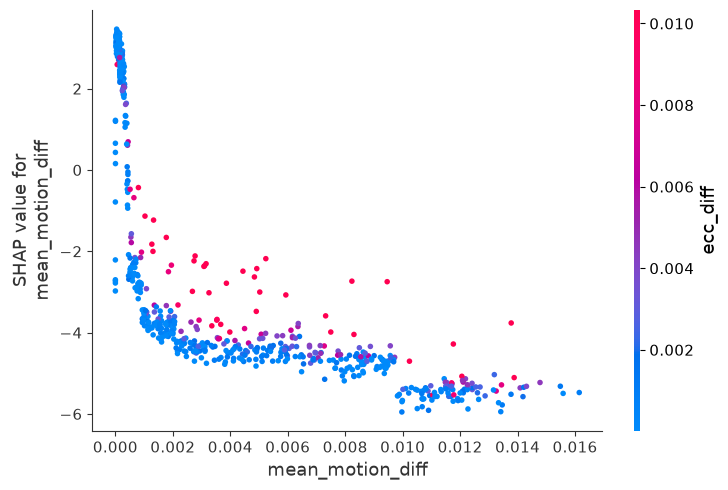

Saved plot to data/shap_dependence_mean_motion.png


In [24]:
import matplotlib.pyplot as plt

# Dependence plot: shows how mean_motion_diff value relates to its SHAP contribution
shap.dependence_plot("mean_motion_diff", shap_values, X_test, feature_names=feature_cols, show=False)
plt.tight_layout()
plt.savefig("data/shap_dependence_mean_motion.png", dpi=120)
plt.show()
print("Saved plot to data/shap_dependence_mean_motion.png")

In [25]:
tuned_pred_final = (y_prob >= best_threshold).astype(int)

fn_mask = (y_test.values == 1) & (tuned_pred_final == 0)
fn_indices = np.where(fn_mask)[0]

print(f"False negatives at tuned threshold: {fn_mask.sum()} out of {(y_test==1).sum()} real positives")

if fn_mask.sum() > 0:
    fn_features = X_test.iloc[fn_indices].copy()
    fn_features["predicted_prob"] = y_prob[fn_indices]
    fn_features = fn_features.sort_values("predicted_prob")
    print("\nMissed close-approach pairs (sorted by how confidently the model was wrong):")
    print(fn_features.to_string())

False negatives at tuned threshold: 1 out of 174 real positives

Missed close-approach pairs (sorted by how confidently the model was wrong):
     incl_diff  raan_diff  ecc_diff  argp_diff  mean_motion_diff  mean_anomaly_diff  predicted_prob
665   0.319072   2.203579  0.140525   2.770056          0.013776           2.492339         0.02189


In [26]:
tp_mask = (y_test.values == 1) & (tuned_pred_final == 1)
tp_features = X_test.iloc[np.where(tp_mask)[0]]

print("\n--- Feature comparison: MISSED vs CAUGHT close approaches ---")
comparison = pd.DataFrame({
    "Missed (mean)": fn_features[feature_cols].mean() if fn_mask.sum() > 0 else None,
    "Caught (mean)": tp_features[feature_cols].mean(),
})
print(comparison)


--- Feature comparison: MISSED vs CAUGHT close approaches ---
                   Missed (mean)  Caught (mean)
incl_diff               0.319072       0.119845
raan_diff               2.203579       0.840861
ecc_diff                0.140525       0.001234
argp_diff               2.770056       0.937940
mean_motion_diff        0.013776       0.000190
mean_anomaly_diff       2.492339       1.242505


In [27]:
# closest_per_pair_5k has the real time_idx for each positive conjunction event
midpoint = 144  # half of 288 time steps = 12 hours

train_positive_pairs = closest_per_pair_5k[closest_per_pair_5k["time_idx"] < midpoint]
test_positive_pairs = closest_per_pair_5k[closest_per_pair_5k["time_idx"] >= midpoint]

print(f"Positive examples - train (first 12h): {len(train_positive_pairs)}")
print(f"Positive examples - test (second 12h): {len(test_positive_pairs)}")

Positive examples - train (first 12h): 464
Positive examples - test (second 12h): 404


In [28]:
train_pos_feats = []
for _, row in train_positive_pairs.iterrows():
    feats = build_features(int(row["sat_i"]), int(row["sat_j"]), orbit_df)
    feats["label"] = 1
    train_pos_feats.append(feats)

test_pos_feats = []
for _, row in test_positive_pairs.iterrows():
    feats = build_features(int(row["sat_i"]), int(row["sat_j"]), orbit_df)
    feats["label"] = 1
    test_pos_feats.append(feats)

# Split negatives proportionally to match, keeping the same 3:1 ratio, random but reproducible
n_train_neg = len(train_pos_feats) * 3
n_test_neg = len(test_pos_feats) * 3

np.random.seed(7)
shuffled_negatives = negative_rows.copy()
np.random.shuffle(shuffled_negatives)

train_neg_feats = shuffled_negatives[:n_train_neg]
test_neg_feats = shuffled_negatives[n_train_neg:n_train_neg + n_test_neg]

temporal_train = pd.DataFrame(train_pos_feats + train_neg_feats)
temporal_test = pd.DataFrame(test_pos_feats + test_neg_feats)

print(f"\nTemporal train set: {len(temporal_train)} rows ({(temporal_train['label']==1).sum()} positive)")
print(f"Temporal test set: {len(temporal_test)} rows ({(temporal_test['label']==1).sum()} positive)")


Temporal train set: 1856 rows (464 positive)
Temporal test set: 1616 rows (404 positive)


In [29]:
X_temp_train = temporal_train[feature_cols]
y_temp_train = temporal_train["label"]
X_temp_test = temporal_test[feature_cols]
y_temp_test = temporal_test["label"]

temporal_model = xgb.XGBClassifier(
    n_estimators=100, max_depth=4, learning_rate=0.1,
    scale_pos_weight=(y_temp_train==0).sum() / (y_temp_train==1).sum(),
    random_state=42
)
temporal_model.fit(X_temp_train, y_temp_train)

temp_probs = temporal_model.predict_proba(X_temp_test)[:, 1]
temp_auc = roc_auc_score(y_temp_test, temp_probs)

print(f"Temporal split ROC-AUC: {temp_auc:.4f}")
print(f"(Compare to random-split ROC-AUC: {cv_scores.mean():.4f})")

Temporal split ROC-AUC: 0.9712
(Compare to random-split ROC-AUC: 0.9738)
